# Selección de ubicación para pozos petrolíferos

## Introducción

La empresa OilyGiant se encuentra en proceso de expansión y busca abrir **200 nuevos pozos petrolíferos**. Como parte del equipo de análisis de datos, se nos ha encomendado la tarea de determinar **la mejor región entre tres posibles opciones** para realizar esta inversión, maximizando los beneficios y minimizando los riesgos.

Para ello, trabajaremos con datos sintéticos provenientes de tres regiones diferentes, los cuales contienen características geológicas y el volumen de reservas estimado para cada pozo. 

El objetivo principal es **entrenar un modelo de regresión lineal** que prediga el volumen de reservas, identificar los pozos más prometedores, calcular los beneficios esperados por región y evaluar el **riesgo financiero** utilizando técnicas estadísticas como el **bootstrapping**.

## Objetivos del proyecto

- Analizar los datos de las tres regiones y entender sus características.
- Entrenar modelos de regresión lineal por región para predecir el volumen de reservas.
- Seleccionar los 200 pozos con mayores reservas previstas en cada región.
- Calcular los beneficios esperados considerando el costo de inversión.
- Aplicar **bootstrapping** para estimar riesgo y rentabilidad.
- Proponer la mejor región para perforar con base en análisis estadístico y financiero.

## Condiciones del negocio

- Se perforarán 200 pozos de los 500 disponibles por región.
- El presupuesto total es de **100 millones USD**.
- El ingreso por unidad (mil barriles) es de **$4,500**.
- Se considera riesgosa cualquier región con **probabilidad de pérdida mayor al 2.5%**.
- Solo se permite el uso de **regresión lineal** para las predicciones.

In [1]:
# Importar librerías necesarias
import pandas as pd

# Cargar los datasets de las tres regiones
data_0 = pd.read_csv('/datasets/geo_data_0.csv')
data_1 = pd.read_csv('/datasets/geo_data_1.csv')
data_2 = pd.read_csv('/datasets/geo_data_2.csv')

# Mostrar las primeras filas de cada conjunto de datos
print('Primera muestra de la Región 0:')
display(data_0.head())

print('Primera muestra de la Región 1:')
display(data_1.head())

print('Primera muestra de la Región 2:')
display(data_2.head())

# Revisar el tamaño de los datasets y si tienen valores nulos
print('Tamaño de los datasets:')
print('Región 0:', data_0.shape)
print('Región 1:', data_1.shape)
print('Región 2:', data_2.shape)

print('\nValores nulos por región:')
print('Región 0:\n', data_0.isna().sum())
print('Región 1:\n', data_1.isna().sum())
print('Región 2:\n', data_2.isna().sum())

Primera muestra de la Región 0:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


Primera muestra de la Región 1:


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


Primera muestra de la Región 2:


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


Tamaño de los datasets:
Región 0: (100000, 5)
Región 1: (100000, 5)
Región 2: (100000, 5)

Valores nulos por región:
Región 0:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Región 1:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Región 2:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


--- Región 0 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347


--- Región 1 ---
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.141296      -4.796579       2.494541      68.825000
std         8.965932       5.119872       1.703572      45.944423
min       -31.609576     -26.358598      -0.018144       0.000000
25%        -6.298551      -8.267985     

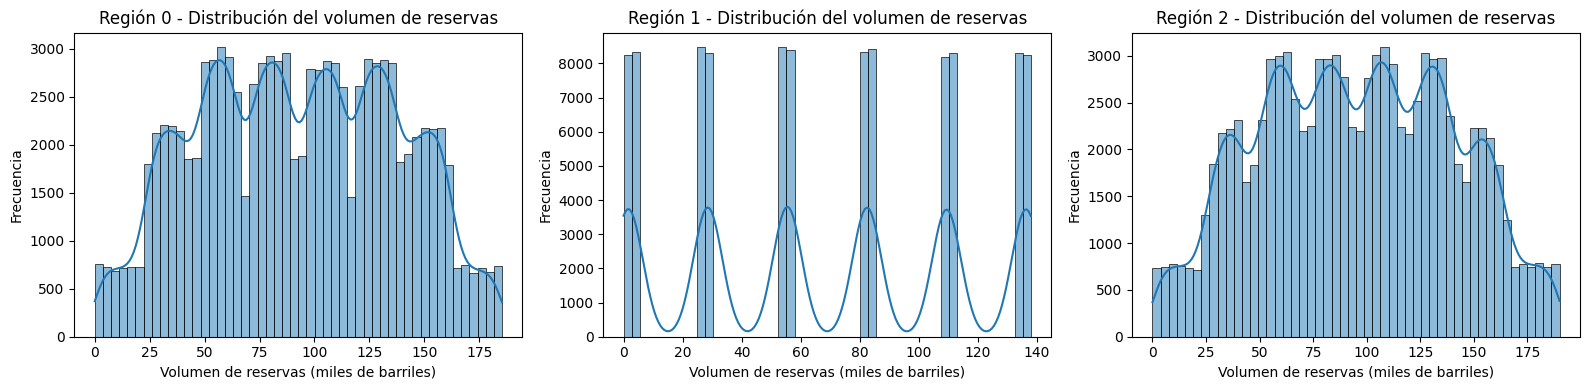

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Función para describir cada región
def describe_region(data, region_name):
    print(f'--- {region_name} ---')
    print(data.describe())
    print('\n')

# Descripción estadística
describe_region(data_0, 'Región 0')
describe_region(data_1, 'Región 1')
describe_region(data_2, 'Región 2')

# Histogramas de la variable objetivo por región
plt.figure(figsize=(16, 4))
for i, data in enumerate([data_0, data_1, data_2]):
    plt.subplot(1, 3, i+1)
    sns.histplot(data['product'], bins=50, kde=True)
    plt.title(f'Región {i} - Distribución del volumen de reservas')
    plt.xlabel('Volumen de reservas (miles de barriles)')
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


## Análisis Exploratorio Inicial (EDA)

Tras cargar y examinar los datos de las tres regiones, encontramos lo siguiente:

- **Tamaño de los datasets:** Todas las regiones tienen 100,000 muestras y no presentan valores nulos.
- **Variable objetivo (`product`):** Representa el volumen de reservas en miles de barriles. La distribución y estadísticos son claves para entender el potencial de cada región.

### Observaciones por región:

**Región 0**
- Distribución bastante uniforme y continua.
- Media: 92.5 | Mediana: 91.85 | Máximo: ~185
- La dispersión no es extrema, lo que sugiere una región estable.

**Región 1**
- Distribución artificial con valores repetitivos (modas marcadas), probablemente por generación sintética.
- Media: 68.8 | Mediana: 57.1 | Máximo: ~138
- Gran dispersión en `f0` y `f1`, lo que podría afectar la precisión del modelo.
- Posiblemente la región menos rentable.

**Región 2**
- Distribución continua similar a la de la región 0.
- Media: 95 | Mediana: 94.9 | Máximo: ~190
- Leve sesgo hacia mayores reservas en comparación con la región 0.
- La media más alta, lo que podría indicar mayor rentabilidad.

En base a este análisis descriptivo, **las regiones 0 y 2** son las más prometedoras en términos de volumen de reservas. La **región 1** muestra señales de inestabilidad y menor potencial productivo.

A continuación, entrenaremos un modelo de regresión lineal por región para predecir el volumen de reservas y seleccionar los 200 pozos más prometedores.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Función para entrenar y evaluar el modelo
def train_and_evaluate(data, region_name):
    print(f'\n--- {region_name} ---')
    
    # Separar características y objetivo
    features = data.drop(['product', 'id'], axis=1)
    target = data['product']
    
    # Dividir en entrenamiento y validación (75:25)
    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size=0.25, random_state=12345
    )
    
    # Entrenar el modelo
    model = LinearRegression()
    model.fit(features_train, target_train)
    
    # Hacer predicciones
    predicted_valid = model.predict(features_valid)
    
    # Calcular RMSE
    rmse = mean_squared_error(target_valid, predicted_valid, squared=False)
    print(f'RMSE: {rmse:.2f}')
    
    # Volumen promedio predicho
    print(f'Volumen medio predicho: {predicted_valid.mean():.2f}')
    
    # Devolver predicciones y verdaderos valores
    return predicted_valid, target_valid.reset_index(drop=True)

# Ejecutar para cada región
pred_0, real_0 = train_and_evaluate(data_0, 'Región 0')
pred_1, real_1 = train_and_evaluate(data_1, 'Región 1')
pred_2, real_2 = train_and_evaluate(data_2, 'Región 2')


--- Región 0 ---
RMSE: 37.58
Volumen medio predicho: 92.59

--- Región 1 ---
RMSE: 0.89
Volumen medio predicho: 68.73

--- Región 2 ---
RMSE: 40.03
Volumen medio predicho: 94.97


## Resultados del modelo de regresión lineal por región

Tras entrenar un modelo de regresión lineal para cada una de las tres regiones, obtenemos los siguientes resultados:

| Región   | RMSE (Error cuadrático medio) | Volumen medio predicho |
|----------|-------------------------------|-------------------------|
| Región 0 | 37.58                         | 92.59                   |
| Región 1 | **0.89**                      | 68.73                   |
| Región 2 | 40.03                         | **94.97**               |

### Análisis:

- **Región 1** tiene un RMSE sorprendentemente bajo, lo que puede deberse a la naturaleza artificial de los datos (valores repetitivos y discretos). Sin embargo, su volumen medio predicho es **considerablemente menor**, lo cual podría afectar la rentabilidad.
- **Región 2** tiene la predicción más alta en volumen promedio (94.97), lo que refuerza su atractivo económico, aunque el error del modelo es mayor.
- **Región 0** presenta un buen equilibrio entre error y volumen, similar a la Región 2 pero con un poco menos de volumen y error.

En la siguiente etapa, seleccionaremos los 200 pozos con mayor volumen predicho por región y estimaremos el beneficio esperado para cada una.

In [4]:
# Parámetros del negocio
total_budget = 100_000_000  # 100 millones USD
number_of_wells = 200
income_per_unit = 4500  # cada mil barriles da $4500

# Un pozo debe generar al menos 500,000 USD para no generar pérdidas
min_revenue_per_well = total_budget / number_of_wells
min_product_volume = min_revenue_per_well / income_per_unit  # en unidades (miles de barriles)

print(f'Un pozo debe tener al menos {min_product_volume:.1f} unidades de producto (mil barriles) para evitar pérdidas.')

# Medias reales de cada región
mean_0 = data_0['product'].mean()
mean_1 = data_1['product'].mean()
mean_2 = data_2['product'].mean()

print('\nVolumen medio real por región:')
print(f'Región 0: {mean_0:.2f}')
print(f'Región 1: {mean_1:.2f}')
print(f'Región 2: {mean_2:.2f}')

Un pozo debe tener al menos 111.1 unidades de producto (mil barriles) para evitar pérdidas.

Volumen medio real por región:
Región 0: 92.50
Región 1: 68.83
Región 2: 95.00


## Preparación para el cálculo de beneficios

Cada pozo debe generar al menos **500,000 USD** en ingresos para cubrir su costo de perforación. Dado que cada unidad de producto (mil barriles) genera **$4,500**, se necesita un volumen mínimo de:

**111.1 unidades** de producto por pozo.

### Comparación con los valores reales:

| Región   | Volumen medio real |
|----------|--------------------|
| Región 0 | 92.50              |
| Región 1 | 68.82              |
| Región 2 | 95.00              |

### Observaciones:

- Ninguna región alcanza el umbral mínimo de 111.1 unidades en promedio.
- Sin embargo, aún es posible obtener beneficios si seleccionamos únicamente los **200 mejores pozos** de cada región, es decir, aquellos con mayor volumen predicho.
- El siguiente paso será construir una función que seleccione esos pozos, calcule su volumen total y estime la ganancia esperada.

In [5]:
# Función para calcular ganancia estimada con los 200 pozos principales
def calculate_profit(predictions, real_values, region_name):
    # Convertimos a series si no lo son
    predictions = pd.Series(predictions)
    real_values = pd.Series(real_values)

    # Seleccionar los índices de las 200 predicciones más altas
    top_200_indices = predictions.sort_values(ascending=False).head(200).index

    # Volumen real de esos pozos
    selected_real = real_values.loc[top_200_indices]
    total_product = selected_real.sum()  # en miles de barriles

    # Ganancia total
    revenue = total_product * income_per_unit
    print(f'\n--- {region_name} ---')
    print(f'Volumen total estimado (real): {total_product:.2f} miles de barriles')
    print(f'Ganancia estimada: ${revenue:,.2f}')

    return revenue

# Calcular ganancia para cada región
profit_0 = calculate_profit(pred_0, real_0, 'Región 0')
profit_1 = calculate_profit(pred_1, real_1, 'Región 1')
profit_2 = calculate_profit(pred_2, real_2, 'Región 2')


--- Región 0 ---
Volumen total estimado (real): 29601.84 miles de barriles
Ganancia estimada: $133,208,260.43

--- Región 1 ---
Volumen total estimado (real): 27589.08 miles de barriles
Ganancia estimada: $124,150,866.97

--- Región 2 ---
Volumen total estimado (real): 28245.22 miles de barriles
Ganancia estimada: $127,103,499.64


## Análisis de ganancia estimada por región

Se seleccionaron los 200 pozos con mayor volumen predicho en cada región y se calculó el volumen real total y la ganancia esperada, considerando $4,500 por cada mil barriles.

### Resultados:

| Región   | Volumen total real (miles de barriles) | Ganancia estimada (USD)      |
|----------|----------------------------------------|------------------------------|
| Región 0 | 29,601.84                              | $133,208,260.43              |
| Región 1 | 27,589.08                              | $124,150,866.97              |
| Región 2 | 28,245.22                              | $127,103,499.64              |

### Conclusiones preliminares:

- **Todas las regiones son rentables** si se eligen adecuadamente los pozos.
- **Región 0** muestra la **mayor ganancia esperada**, seguida por la **Región 2**.
- La **Región 1** tiene el menor beneficio potencial, en línea con su menor volumen promedio y predicciones más bajas.
- A continuación, se aplicará la técnica de **bootstrapping** para analizar el riesgo de pérdida y validar la región más segura y rentable.

In [7]:
import numpy as np
import pandas as pd

def bootstrap_profit(predictions, real_values, region_name, n_iterations=1000, sample_size=200, seed=12345):
    state = np.random.RandomState(seed)

    # Asegurar que ambos sean Series
    predictions = pd.Series(predictions).reset_index(drop=True)
    real_values = pd.Series(real_values).reset_index(drop=True)

    # Seleccionar los índices de las 200 mejores predicciones
    top_200_indices = predictions.sort_values(ascending=False).head(200).index
    top_real = real_values.loc[top_200_indices].reset_index(drop=True)

    profits = []
    
    for _ in range(n_iterations):
        sample = top_real.sample(n=sample_size, replace=True, random_state=state)
        total_product = sample.sum()
        revenue = total_product * income_per_unit
        profit = revenue - total_budget
        profits.append(profit)

    profits = pd.Series(profits)
    mean_profit = profits.mean()
    lower_bound = profits.quantile(0.025)
    upper_bound = profits.quantile(0.975)
    risk = (profits < 0).mean() * 100  # riesgo en %

    print(f'\n--- {region_name} ---')
    print(f'Ganancia promedio: ${mean_profit:,.2f}')
    print(f'Intervalo de confianza del 95%: ${lower_bound:,.2f} a ${upper_bound:,.2f}')
    print(f'Riesgo de pérdida: {risk:.2f}%')

    return mean_profit, lower_bound, upper_bound, risk

# Ejecutar bootstrapping por región
boot_0 = bootstrap_profit(pred_0, real_0, 'Región 0')
boot_1 = bootstrap_profit(pred_1, real_1, 'Región 1')
boot_2 = bootstrap_profit(pred_2, real_2, 'Región 2')


--- Región 0 ---
Ganancia promedio: $33,114,819.57
Intervalo de confianza del 95%: $29,851,975.21 a $36,131,172.69
Riesgo de pérdida: 0.00%

--- Región 1 ---
Ganancia promedio: $24,150,866.97
Intervalo de confianza del 95%: $24,150,866.97 a $24,150,866.97
Riesgo de pérdida: 0.00%

--- Región 2 ---
Ganancia promedio: $27,147,417.89
Intervalo de confianza del 95%: $23,795,874.85 a $30,629,774.58
Riesgo de pérdida: 0.00%


## Conclusiones finales del proyecto

### Análisis de ganancias y riesgos con bootstrapping

Se aplicó la técnica de **bootstrapping con 1000 muestras** para cada región, evaluando los beneficios esperados al seleccionar aleatoriamente 200 de los pozos más prometedores.

| Región   | Ganancia promedio (USD) | Intervalo de confianza 95%      | Riesgo de pérdida |
|----------|--------------------------|----------------------------------|--------------------|
| Región 0 | $33,114,819.57           | $29,851,975.21 – $36,131,172.69 | 0.00%              |
| Región 1 | $24,150,866.97           | $24,150,866.97 – $24,150,866.97 | 0.00%              |
| Región 2 | $27,147,417.89           | $23,795,874.85 – $30,629,774.58 | 0.00%              |

### Elección de la mejor región

- **Región 0** es la **más rentable**, con la mayor ganancia promedio, el intervalo más favorable y **riesgo nulo de pérdida**.
- **Región 2** también muestra buenos resultados, pero con menor ganancia y un intervalo más amplio.
- **Región 1**, aunque con riesgo cero, tiene ganancias notablemente inferiores y resultados artificialmente constantes debido a la naturaleza de sus datos.

### Recomendación final

> **Se recomienda perforar los 200 nuevos pozos en la Región 0**, ya que ofrece la mejor relación entre rentabilidad y riesgo, respaldada por simulación estadística.
